### HW-5 : FFT

#### Step 0

In [1]:
# Import necessary libraries
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

# 讓輸出的圖片可以更加清晰
%config InlineBackend.figure_format = 'retina'

In [2]:
# Load the input data from the .mat file
mat = loadmat("FFTInput32.mat") # 讀進來是 dict
print(mat.keys()) # 看看 .mat 檔有那些變數可以用

dict_keys(['__header__', '__version__', '__globals__', 'FFTIn32'])


In [3]:
# 前面得到 Key 是 FFTIn32，拿出來並攤平成 1D array
x = mat["FFTIn32"].squeeze()

# 判斷長度是否為 32
assert x.size == 32, f"size is {x.size}, not 32" # assert condition, message

# 轉成 complex128 = real (fp64) + imag (fp64)
x = x.astype(np.complex128)

# 用 np.fft 作為 Golden Result
X_ref = np.fft.fft(x)

# print("x.shape =", x.shape) # .shape 是 tuple，因此會輸出 (32,)
# print("Input Data :")

# # 看五組 Input Data 作為參考
# for i, v in enumerate(x[:5]): # 使用 enumerate 可以同時得到 index 和 value
#     print(f"x[{i}] = {v.real:10.6f} {v.imag:+8.6f}j")

# # 看五組 Golden Output Result 作為參考
# print("\nGolden Output Result :")
# for i, v in enumerate(X_ref[:5]):
#     print(f"x[{i}] = {v.real:10.6f} {v.imag:+8.6f}j")

#### Step 1

In [5]:
def bit_reverse(index, n_bits):
    ''' bit-reversed order function '''
    b = format(index, f"0{n_bits}b") # 把整數 index 轉成固定二進制
    return int(b[::-1], 2) # [::-1] reversed, using int(b,2) transform binary to decimal

def reorder_from_bit_reversed(X_br):
    ''' do bit-reversal order function in output '''
    N = len(X_br)
    n_bits = int(np.log2(N)) # 計算出有幾個 bit
    X_nat = np.zeros(N, dtype=np.complex128) # Create a all zero matrix
    for k in range(N): # 把他一個一個搬到正確的位置
        X_nat[bit_reverse(k, n_bits)] = X_br[k]
    return X_nat

def quantize(x, wf):
    """ complex truncate to wf fractional bits """
    scale = 2 ** wf
    return np.floor(x.real * scale) / scale + 1j * np.floor(x.imag * scale) / scale

def sdf_fft_32(x, wf_list=None, wf_twiddle=None):
    """ 32-point SDF DIF FFT (in-place radix-2) """
    N = 32
    data = x.copy() # 保護原始資料 -> copy

    for stage in range(5): # 32 個 Imput, 因此有 5 個 Stage
        half = N >> (stage + 1) # 代表前半跟後半各有幾個點
        group_size = N >> stage # 代表一組有幾個點
        wf = wf_list[stage] if wf_list is not None else None # 該 Stage 的 wf

        for gs in range(0, N, group_size):
            for k in range(half):
                a = data[gs + k] # 前半
                b = data[gs + k + half] # 後半  

                # Twiddle factor
                W = np.exp(-1j * 2 * np.pi * k * (1 << stage) / N)
                if wf_twiddle is not None:
                    W = quantize(W, wf_twiddle)

                s = a + b # butterfly sum 
                d = (a - b) * W # butterfly diff × twiddle

                if wf is not None:
                    s = quantize(s, wf)
                    d = quantize(d, wf)

                # 寫回原矩陣，給下一個 Stage 做 Reuse
                data[gs + k] = s
                data[gs + k + half] = d
    return data

def compute_sqnr(X_ref, X_quant):
    ''' compute SQNR (Signal-to-Quantization-Noise Ratio) '''
    signal = np.mean(np.abs(X_ref) ** 2)
    noise  = np.mean(np.abs(X_quant - X_ref) ** 2)
    if noise == 0:
        return np.inf
    return 10 * np.log10(signal / noise)

# 執行 SDF FFT，輸出 bit-reversed order
X_br   = sdf_fft_32(x)
n_bits = 5

# Bit-reversal 重排並與 Golden Result 比較
X_nat  = reorder_from_bit_reversed(X_br)

# 印出表格
print(f"{'Pos k':>6}  {'Freq Index':>10}  {'SDF Output':>40}")
print("-" * 62)
for k in range(32):
    freq_idx = bit_reverse(k, n_bits)
    v = X_br[k]
    print(f"k={k:2d}    X[{freq_idx:2d}]       {v.real:+12.6f} {v.imag:+12.6f}j")


 Pos k  Freq Index                                SDF Output
--------------------------------------------------------------
k= 0    X[ 0]          -1.000000    -1.000000j
k= 1    X[16]          -1.000000    +1.000000j
k= 2    X[ 8]          +1.000000    -1.000000j
k= 3    X[24]          +1.000000    -1.000000j
k= 4    X[ 4]          -1.000000    +1.000000j
k= 5    X[20]          +1.000000    -1.000000j
k= 6    X[12]          +1.000000    +1.000000j
k= 7    X[28]          +1.000000    -1.000000j
k= 8    X[ 2]          -1.000000    -1.000000j
k= 9    X[18]          +1.000000    -1.000000j
k=10    X[10]          -1.000000    +1.000000j
k=11    X[26]          -1.000000    -1.000000j
k=12    X[ 6]          +1.000000    -1.000000j
k=13    X[22]          -1.000000    +1.000000j
k=14    X[14]          -1.000000    +1.000000j
k=15    X[30]          +1.000000    +1.000000j
k=16    X[ 1]          -1.000000    -1.000000j
k=17    X[17]          -1.000000    +1.000000j
k=18    X[ 9]          +1.0000

#### Step 2

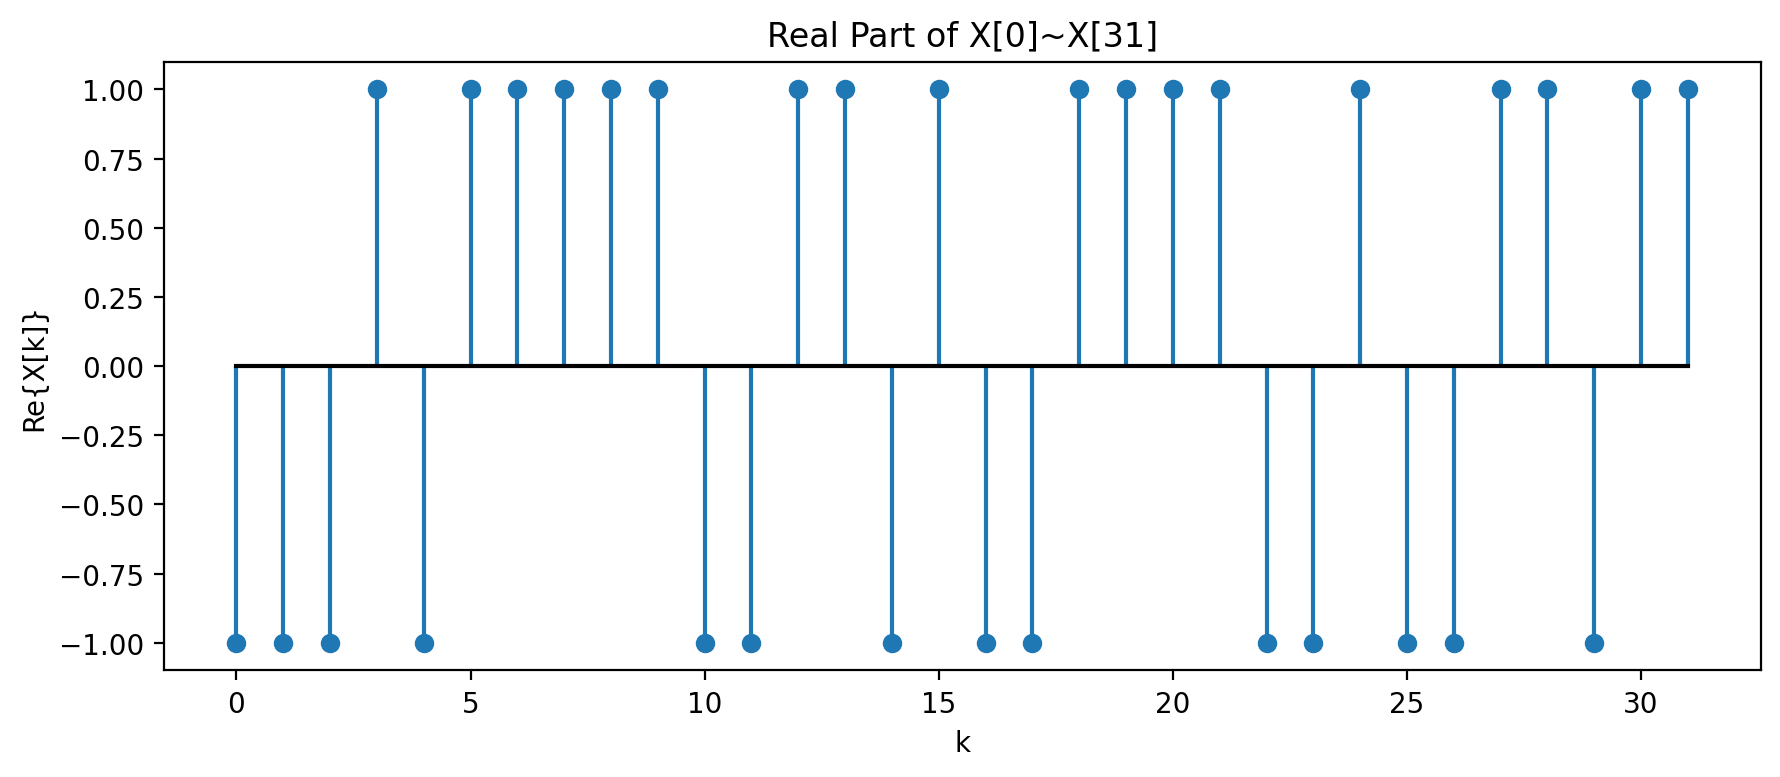

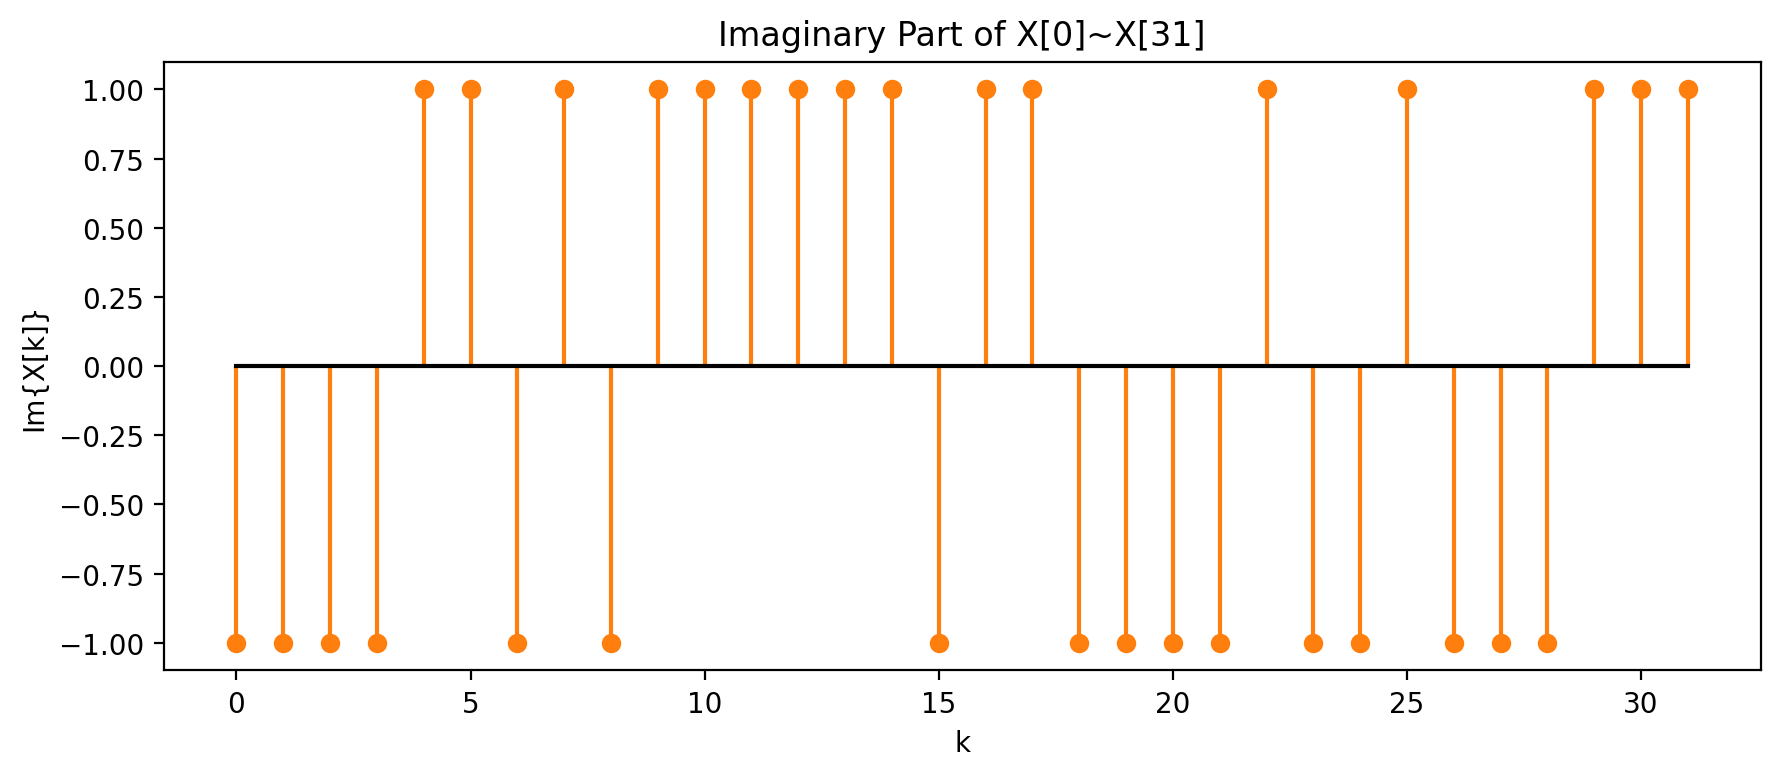

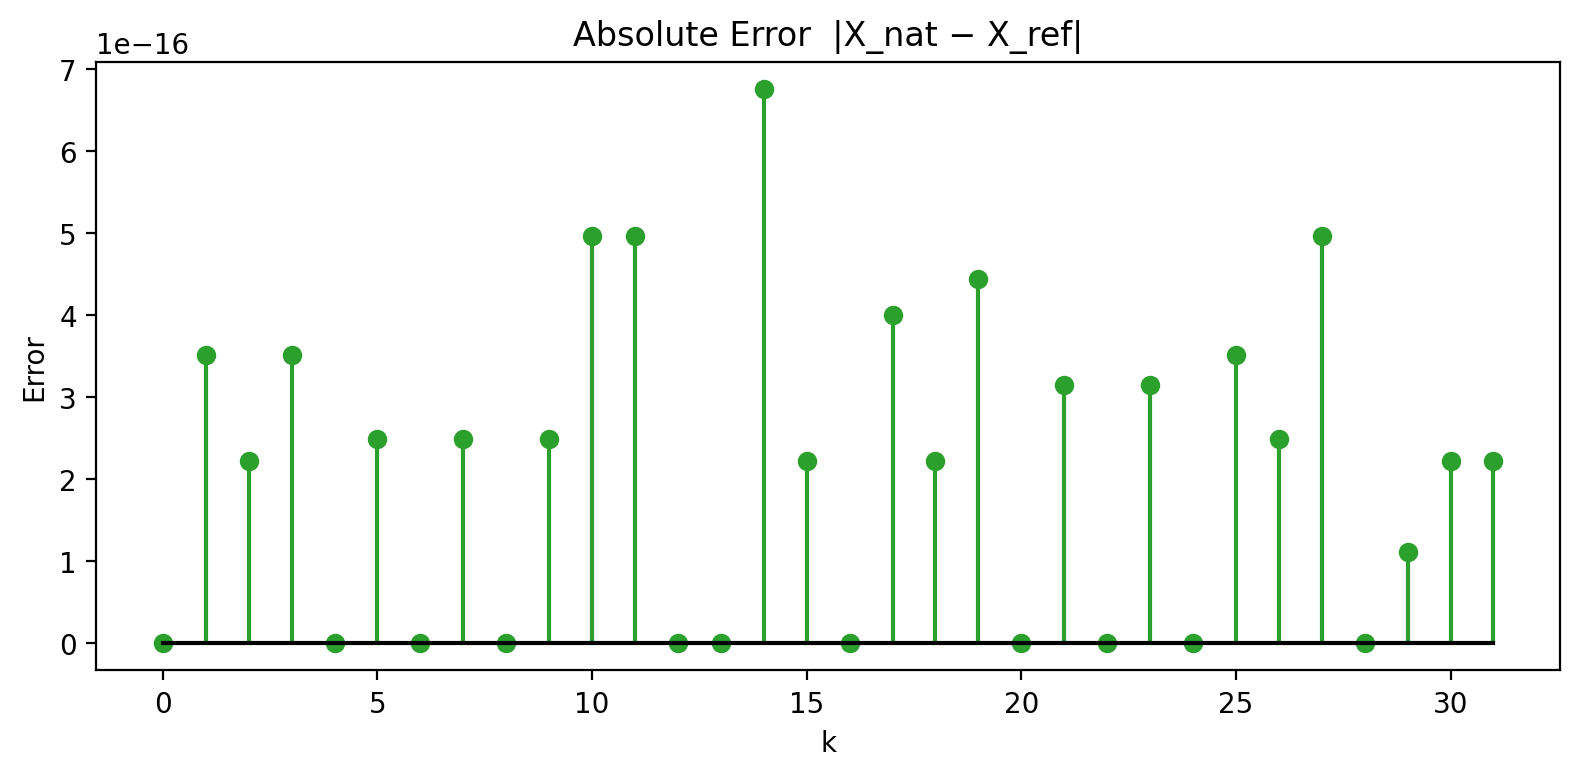

max|X_nat - X_ref|  = 6.753223014464258e-16


In [6]:
k_axis = np.arange(32)

# Real part plot
fig_real, ax_real = plt.subplots(figsize=(9, 4))
ax_real.stem(k_axis, X_nat.real, markerfmt='C0o', linefmt='C0-', basefmt='k-')
ax_real.set_title("Real Part of X[0]~X[31]")
ax_real.set_xlabel("k")
ax_real.set_ylabel("Re{X[k]}")
plt.tight_layout()
plt.show()

# Imaginary part plot
fig_imag, ax_imag = plt.subplots(figsize=(9, 4))
ax_imag.stem(k_axis, X_nat.imag, markerfmt='C1o', linefmt='C1-', basefmt='k-')
ax_imag.set_title("Imaginary Part of X[0]~X[31]")
ax_imag.set_xlabel("k")
ax_imag.set_ylabel("Im{X[k]}")
plt.tight_layout()
plt.show()

error = np.abs(X_nat - X_ref)
fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(k_axis, error, markerfmt='C2o', linefmt='C2-', basefmt='k-')
ax.set_title("Absolute Error  |X_nat − X_ref|")
ax.set_xlabel("k")
ax.set_ylabel("Error")
plt.tight_layout()
plt.show()
print("max|X_nat - X_ref|  =", np.max(np.abs(X_nat - X_ref)))


#### Step 3

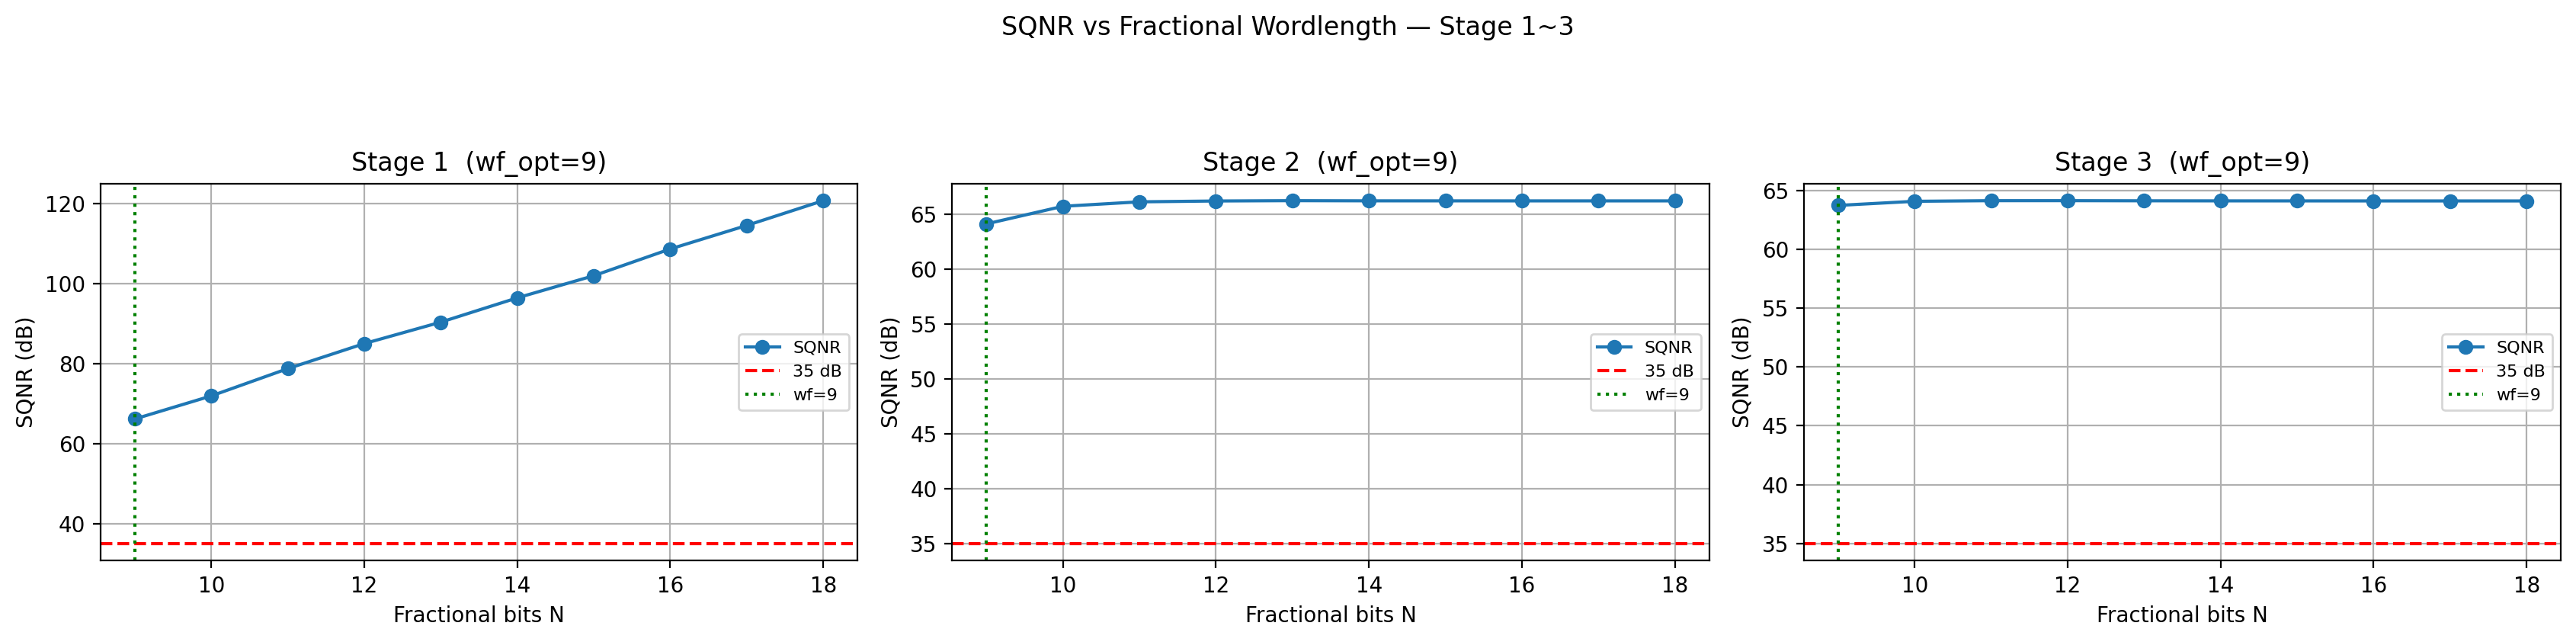

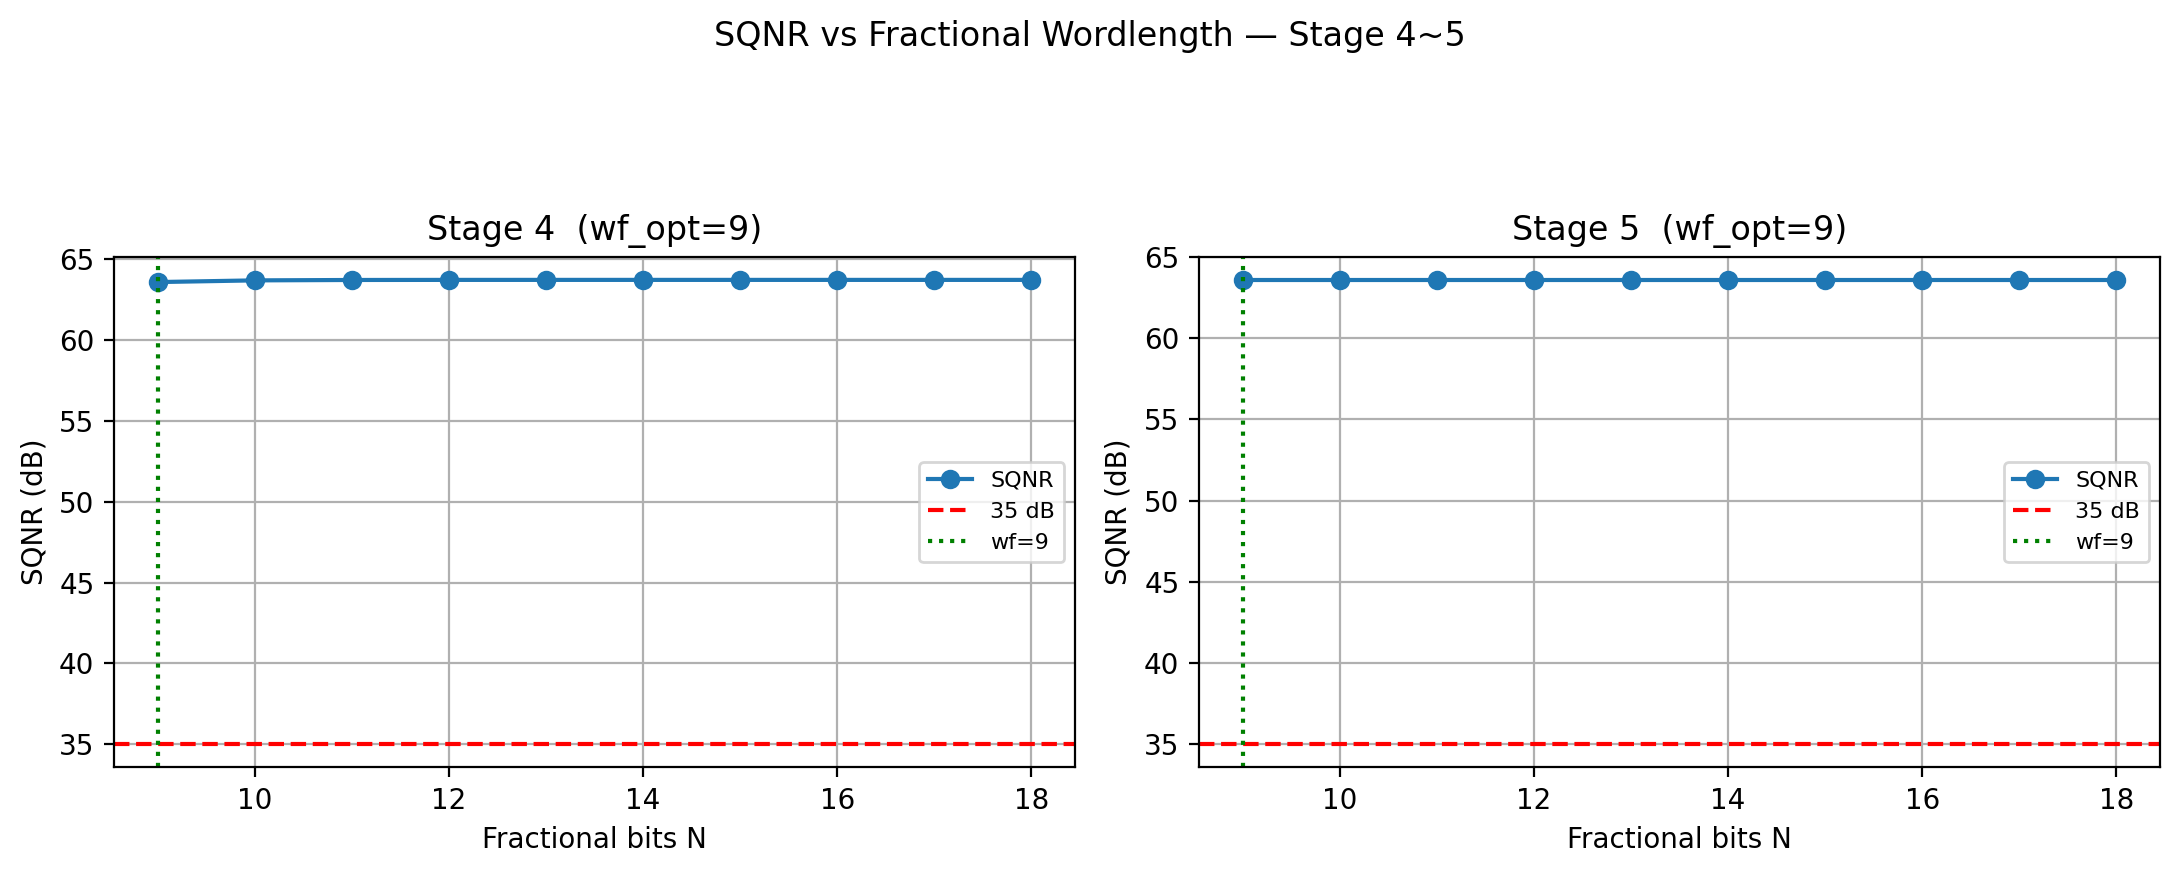

<Figure size 640x480 with 0 Axes>

Selected wf per stage: [9, 9, 9, 9, 9]


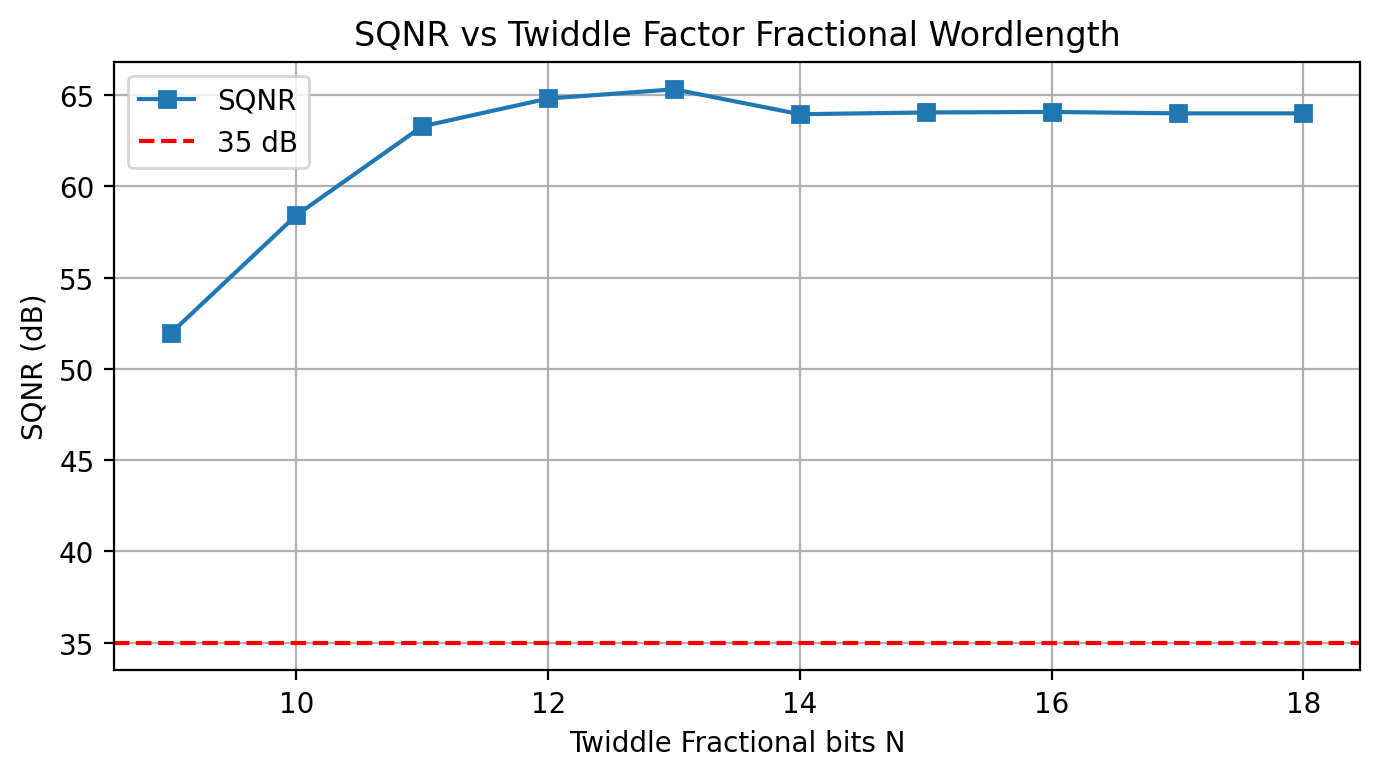

Selected twiddle wordlength: 9


In [7]:
# 96 samples from S = {1+j, 1-j, -1+j, -1-j}
np.random.seed(42) # Fixed Random Seed
S = np.array([1+1j, 1-1j, -1+1j, -1-1j]) # Sample Set
own_96 = S[np.random.randint(0, 4, size=96)] # 從 S 隨機抽 96 個 Index

# 把 96 筆資料切分成 3 個 32-point 的 FFT，算整體平均 SQNR
def eval_sqnr(samples_96, wf_list, wf_twiddle=None): 
    """ compute average SQNR for 96 sample """
    sig, noise = 0.0, 0.0
    for i in range(3):
        x_sym = samples_96[i*32:(i+1)*32]
        X_ref_sym = np.fft.fft(x_sym)
        X_q = sdf_fft_32(x_sym, wf_list=wf_list, wf_twiddle=wf_twiddle)
        X_q_nat = reorder_from_bit_reversed(X_q)
        sig += np.mean(np.abs(X_ref_sym) ** 2)
        noise += np.mean(np.abs(X_q_nat - X_ref_sym) ** 2)
    return 10 * np.log10(sig / noise) if noise > 0 else np.inf

wf_range = list(range(9, 19))
wf_fixed = [None] * 5   # 逐 stage 填入選定的 wf

# (a)~(d) Stage-by-stage SQNR
fig1, axes1 = plt.subplots(1, 3, figsize=(17, 4))  # 第一列 3 張
fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4))  # 第二列 2 張

for stage in range(5):
    sqnr_vals = []
    for wf in wf_range:
        wf_trial = wf_fixed.copy()
        wf_trial[stage] = wf
        sqnr_vals.append(eval_sqnr(own_96, wf_trial))

    wf_opt = next((w for w, s in zip(wf_range, sqnr_vals) if s >= 35), wf_range[-1])
    wf_fixed[stage] = wf_opt

    if stage < 3:
        ax = axes1[stage]
        fig = fig1
    else:
        ax = axes2[stage-3]
        fig = fig2

    ax.plot(wf_range, sqnr_vals, 'o-', label='SQNR')
    ax.axhline(35, color='r', linestyle='--', label='35 dB')
    ax.axvline(wf_opt, color='g', linestyle=':', label=f'wf={wf_opt}')
    ax.set_title(f"Stage {stage+1}  (wf_opt={wf_opt})")
    ax.set_xlabel("Fractional bits N")
    ax.set_ylabel("SQNR (dB)")
    ax.legend(fontsize=8)
    ax.grid(True)

fig1.suptitle("SQNR vs Fractional Wordlength — Stage 1~3", y=1.04)
fig1.tight_layout(rect=[0, 0, 1, 0.94])
fig2.suptitle("SQNR vs Fractional Wordlength — Stage 4~5", y=1.08)
fig2.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

plt.suptitle("SQNR vs Fractional Wordlength — Stage by Stage", y=1.02)
plt.tight_layout()
plt.show()
print("Selected wf per stage:", wf_fixed)

# (e) Twiddle factor wordlength sweep（固定各 stage wf，掃 twiddle）
sqnr_twiddle = [eval_sqnr(own_96, wf_fixed, wf_twiddle=wf_tw) for wf_tw in wf_range]

plt.figure(figsize=(7, 4))
plt.plot(wf_range, sqnr_twiddle, 's-', label='SQNR')
plt.axhline(35, color='r', linestyle='--', label='35 dB')
plt.xlabel("Twiddle Fractional bits N")
plt.ylabel("SQNR (dB)")
plt.title("SQNR vs Twiddle Factor Fractional Wordlength")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

wf_twiddle_opt = next((w for w, s in zip(wf_range, sqnr_twiddle) if s >= 35), wf_range[-1])
print(f"Selected twiddle wordlength: {wf_twiddle_opt}")

#### Step 6

In [10]:
# Fixed-Point Wordlength Summary
# 用 np.fft 實際輸出的最大值估算全域整數位元數

# FFTInput32.mat
X_fft_in32  = np.fft.fft(x)
max_in32    = float(np.max(np.maximum(np.abs(X_fft_in32.real), np.abs(X_fft_in32.imag))))

# own_96：對 3 個 symbol 分別算 FFT，取最大值
max_own = 0.0
for i in range(3):
    X_sym   = np.fft.fft(own_96[i*32:(i+1)*32])
    max_own = max(max_own,
                  float(np.max(np.maximum(np.abs(X_sym.real), np.abs(X_sym.imag)))))

# wi = floor(log2(max)) + 1(magnitude) + 1(sign)
wi_in32 = int(np.floor(np.log2(max(max_in32, 1.0)))) + 2
wi_own  = int(np.floor(np.log2(max(max_own,  1.0)))) + 2

# 取兩組輸入的較大者，+1 guard bit for √2 from complex multiplication
wi_global    = max(wi_in32, wi_own) + 1
wf_global    = wf_fixed[0]          # Step 3 選出，各 stage 皆相同
total_global = wi_global + wf_global

# Twiddle ROM: |W| ≤ 1 → 1S1I → wi = 2
wi_twiddle    = 2
total_twiddle = wi_twiddle + wf_twiddle_opt

print("=" * 58)
print("  FFT Output Range Analysis  (via np.fft)")
print("=" * 58)
print(f"  FFTInput32.mat  max|Re/Im(X)| = {max_in32:8.4f}  → wi = {wi_in32}")
print(f"  own_96          max|Re/Im(X)| = {max_own:8.4f}  → wi = {wi_own}")
print(f"  +1 guard bit for complex mult √2")
print("-" * 58)
print(f"  Global wi            = {wi_global}")
print(f"  Global wf            = {wf_global}")
print(f"  Global total         = {total_global} bits  (1S{wi_global-1}I{wf_global}F)")
print(f"  Representable range  = [{-2**(wi_global-1):.0f}, {2**(wi_global-1):.0f})")
print("=" * 58)
print(f"  Twiddle ROM total    = {total_twiddle} bits  (1S1I{wf_twiddle_opt}F)")


  FFT Output Range Analysis  (via np.fft)
  FFTInput32.mat  max|Re/Im(X)| =   1.0000  → wi = 2
  own_96          max|Re/Im(X)| =  16.0000  → wi = 6
  +1 guard bit for complex mult √2
----------------------------------------------------------
  Global wi            = 7
  Global wf            = 9
  Global total         = 16 bits  (1S6I9F)
  Representable range  = [-64, 64)
  Twiddle ROM total    = 11 bits  (1S1I9F)


In [11]:
# Step 6 : Twiddle Factor ROM Values 
# ROM32 (Stage 1) 存 16 phases 的第一象限 → k=0..7 (8 entries)
# ROM16/ROM8/ROM4 的值全為 ROM32 的子集：
#   ROM16 (k=0,2,4,6) | ROM8 (k=0,4) | ROM4 (k=0)

wf_tw = wf_twiddle_opt   # 沿用 Step 3 選出的 twiddle wf

def quantize_rom(val, wf):
    """ truncate to wf fractional bits, return fixed-point integer representation """
    scale = 2 ** wf
    q = np.floor(val * scale) / scale          # 量化後實數值
    fp = int(np.floor(val * scale))            # 對應的 fixed-point integer
    return q, fp

N = 32
print(f"Twiddle ROM  (wf = {wf_tw},  total = {2 + wf_tw} bits)")
print(f"W_32^k = cos(2π·k/32) − j·sin(2π·k/32)")
print()

# ROM32 第一象限 k=0..7
rom32 = []
print("=" * 72)
print(f"ROM32  (Stage 1)  — 16 first-quadrant entries")
print(f"{'k':>4}  {'cos (float)':>14}  {'cos_q':>14}  {'cos_fp':>8}  "
      f"{'sin (float)':>14}  {'sin_q':>14}  {'sin_fp':>8}")
print("-" * 72)
for k in range(16):
    angle  = 2 * np.pi * k / N
    cos_f  = np.cos(angle)
    sin_f  = np.sin(angle)
    cos_q, cos_fp = quantize_rom(cos_f, wf_tw)
    sin_q, sin_fp = quantize_rom(sin_f, wf_tw)
    rom32.append((cos_q, sin_q, cos_fp, sin_fp))
    print(f"{k:>4}  {cos_f:>14.8f}  {cos_q:>14.8f}  {cos_fp:>8d}  "
          f"{sin_f:>14.8f}  {sin_q:>14.8f}  {sin_fp:>8d}")

# ROM16 (k=0,2,4,6) → Stage 2
print()
print("=" * 72)
print("ROM16  (Stage 2)  — subset of ROM32  k = 0, 2, 4, 6")
print(f"{'k_rom16':>8}  {'k_rom32':>8}  {'cos_q':>14}  {'cos_fp':>8}  {'sin_q':>14}  {'sin_fp':>8}")
print("-" * 72)
for ki, k32 in enumerate([0, 2, 4, 6]):
    cos_q, sin_q, cos_fp, sin_fp = rom32[k32]
    print(f"{ki:>8}  {k32:>8}  {cos_q:>14.8f}  {cos_fp:>8d}  {sin_q:>14.8f}  {sin_fp:>8d}")

# ROM8 (k=0,4) → Stage 3
print()
print("=" * 72)
print("ROM8   (Stage 3)  — subset of ROM32  k = 0, 4")
print(f"{'k_rom8':>8}  {'k_rom32':>8}  {'cos_q':>14}  {'cos_fp':>8}  {'sin_q':>14}  {'sin_fp':>8}")
print("-" * 72)
for ki, k32 in enumerate([0, 4]):
    cos_q, sin_q, cos_fp, sin_fp = rom32[k32]
    print(f"{ki:>8}  {k32:>8}  {cos_q:>14.8f}  {cos_fp:>8d}  {sin_q:>14.8f}  {sin_fp:>8d}")

# ROM4 (Stage 4): k=0 → W=1+0j, k=1 → W=0-j
# W_32^8 = cos(π/2) - j*sin(π/2) = 0 - j  → cos=0, sin=+1 (正值存入 ROM)
print()
print("=" * 72)
print("ROM4   (Stage 4)  — k=0: W=1+0j,  k=1: W=0−j  (trivial, hardcode)")
cos_q, sin_q, cos_fp, sin_fp = rom32[0]
print(f"  k=0 : cos_fp = {cos_fp:>5d}  sin_fp = {sin_fp:>5d}  (= 1 + 0j)")
print(f"  k=1 : cos_fp = {0:>5d}  sin_fp = {2**wf_tw:>5d}  (= 0 − j,  sin=+1 stored)")


Twiddle ROM  (wf = 9,  total = 11 bits)
W_32^k = cos(2π·k/32) − j·sin(2π·k/32)

ROM32  (Stage 1)  — 16 first-quadrant entries
   k     cos (float)           cos_q    cos_fp     sin (float)           sin_q    sin_fp
------------------------------------------------------------------------
   0      1.00000000      1.00000000       512      0.00000000      0.00000000         0
   1      0.98078528      0.98046875       502      0.19509032      0.19335938        99
   2      0.92387953      0.92382812       473      0.38268343      0.38085938       195
   3      0.83146961      0.83007812       425      0.55557023      0.55468750       284
   4      0.70710678      0.70703125       362      0.70710678      0.70703125       362
   5      0.55557023      0.55468750       284      0.83146961      0.83007812       425
   6      0.38268343      0.38085938       195      0.92387953      0.92382812       473
   7      0.19509032      0.19335938        99      0.98078528      0.98046875       502


#### Step 7

In [16]:
# Export FFTIn32 to hardware .dat (1S6I9F) - Real/Imag separated
W = 16
F = 9
OUT_DAT_REAL = "./00_TESTBED/src/Q1_REAL.dat"
OUT_DAT_IMAG = "./00_TESTBED/src/Q1_IMAG.dat"

SCALE = 1 << F
MIN_INT = -(1 << (W - 1))        # -32768
MAX_INT = (1 << (W - 1)) - 1     # +32767
MASK = (1 << W) - 1              # 0xFFFF

def q_signed_1s6i9f(v):
    # round-to-nearest + saturation
    q = int(np.round(v * SCALE))
    q = max(MIN_INT, min(MAX_INT, q))
    return q

def to_u16(q):
    # signed -> 16-bit two's complement unsigned
    return q & MASK

with open(OUT_DAT_REAL, "w") as fr, open(OUT_DAT_IMAG, "w") as fi:
    for s in x:
        i_q = q_signed_1s6i9f(np.real(s))   # Real part
        q_q = q_signed_1s6i9f(np.imag(s))   # Imag part

        i_u = to_u16(i_q)
        q_u = to_u16(q_q)

        # each line stores one 16-bit sample in hex (4 hex chars)
        fr.write(f"{i_u:04X}\n")
        fi.write(f"{q_u:04X}\n")

print(f"Done. Wrote {OUT_DAT_REAL}")
print(f"Done. Wrote {OUT_DAT_IMAG}")

Done. Wrote ./00_TESTBED/src/Q1_REAL.dat
Done. Wrote ./00_TESTBED/src/Q1_IMAG.dat


#### Step 8


max |Re error| = 0.019531
max |Im error| = 0.011719
max |error|    = 0.021837
SQNR vs Step 1 (float)  = 45.36 dB
SQNR vs np.fft (golden) = 45.36 dB


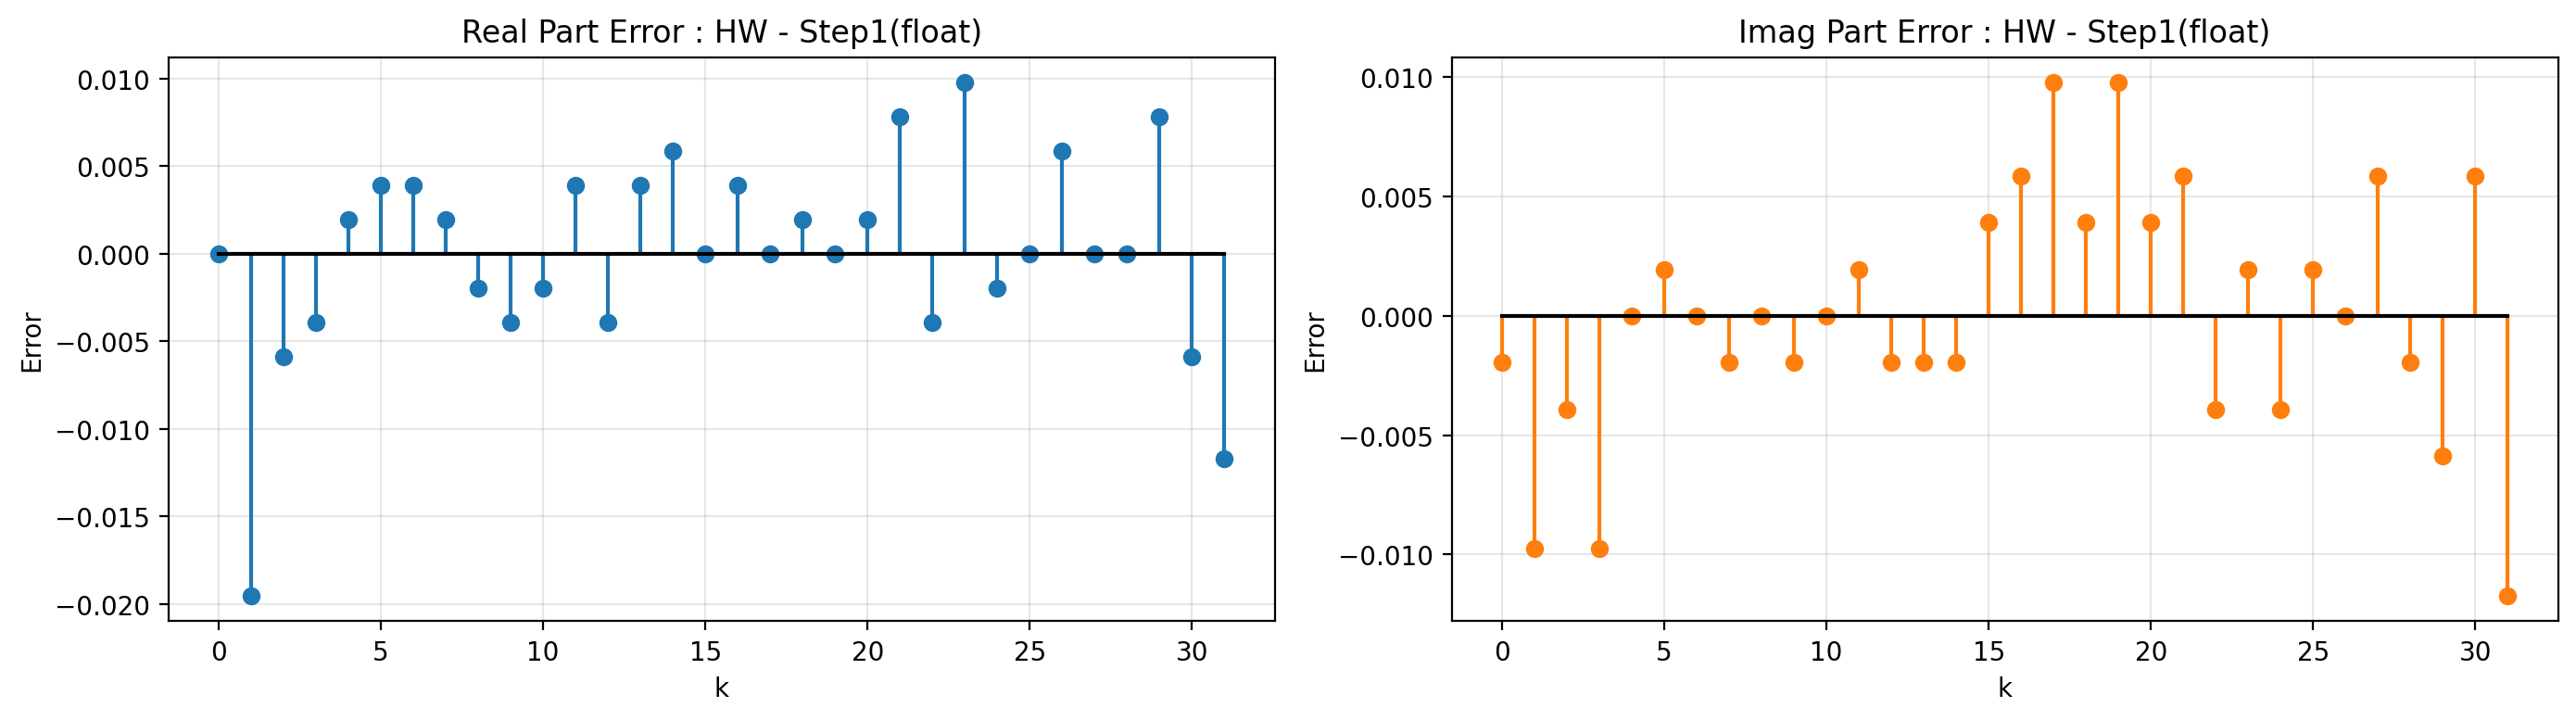

In [15]:
SDFOUT_RE = "./00_TESTBED/src/Q1_BROutRe.dat"
SDFOUT_IM = "./00_TESTBED/src/Q1_BROutIm.dat"

def from_u16(u):
    """ Cell 45 to_u16() 的反函式: 16-bit 兩補數 → signed int """
    return u - (1 << W) if u >= (1 << (W - 1)) else u

def parse_1s6i9f_hex(path):
    """ 讀 hex 檔 (一行一個 16-bit 值) → 1S6I9F 浮點 array """
    with open(path, "r") as f:
        return np.array(
            [from_u16(int(s, 16) & MASK) / SCALE
             for s in f if s.strip()],
            dtype=np.float64,
        )

# 讀 RTL 輸出並轉成複數
re_hw = parse_1s6i9f_hex(SDFOUT_RE)
im_hw = parse_1s6i9f_hex(SDFOUT_IM)
X_hw_br  = re_hw + 1j * im_hw

#X_hw_nat = reorder_from_bit_reversed(X_hw_br)
X_hw_nat = X_hw_br

err_real = X_hw_nat.real - X_nat.real
err_imag = X_hw_nat.imag - X_nat.imag
err_abs  = np.abs(X_hw_nat - X_nat)
print(f"\nmax |Re error| = {np.max(np.abs(err_real)):.6f}")
print(f"max |Im error| = {np.max(np.abs(err_imag)):.6f}")
print(f"max |error|    = {np.max(err_abs):.6f}")
print(f"SQNR vs Step 1 (float)  = {compute_sqnr(X_nat, X_hw_nat):.2f} dB")
print(f"SQNR vs np.fft (golden) = {compute_sqnr(X_ref, X_hw_nat):.2f} dB")

# 畫圖
k_axis = np.arange(32)
fig, (ax_r, ax_i) = plt.subplots(1, 2, figsize=(14, 4))
ax_r.stem(k_axis, err_real, markerfmt='C0o', linefmt='C0-', basefmt='k-')
ax_r.set_title("Real Part Error : HW - Step1(float)")
ax_r.set_xlabel("k"); ax_r.set_ylabel("Error"); ax_r.grid(alpha=0.3)
ax_i.stem(k_axis, err_imag, markerfmt='C1o', linefmt='C1-', basefmt='k-')
ax_i.set_title("Imag Part Error : HW - Step1(float)")
ax_i.set_xlabel("k"); ax_i.set_ylabel("Error"); ax_i.grid(alpha=0.3)
plt.tight_layout(); plt.show()


#### Step 9

In [14]:
OUT_Q3_REAL = "./00_TESTBED/src/Q3_REAL.dat"
OUT_Q3_IMAG = "./00_TESTBED/src/Q3_IMAG.dat"

with open(OUT_Q3_REAL, "w") as fr, open(OUT_Q3_IMAG, "w") as fi:
    for s in own_96:
        i_q = q_signed_1s6i9f(np.real(s))
        q_q = q_signed_1s6i9f(np.imag(s))
        fr.write(f"{to_u16(i_q):04X}\n")
        fi.write(f"{to_u16(q_q):04X}\n")

print(f"Done. Wrote {OUT_Q3_REAL}")
print(f"Done. Wrote {OUT_Q3_IMAG}")


Done. Wrote ./00_TESTBED/src/Q3_REAL.dat
Done. Wrote ./00_TESTBED/src/Q3_IMAG.dat


96-sample streaming SQNR = 55.44 dB


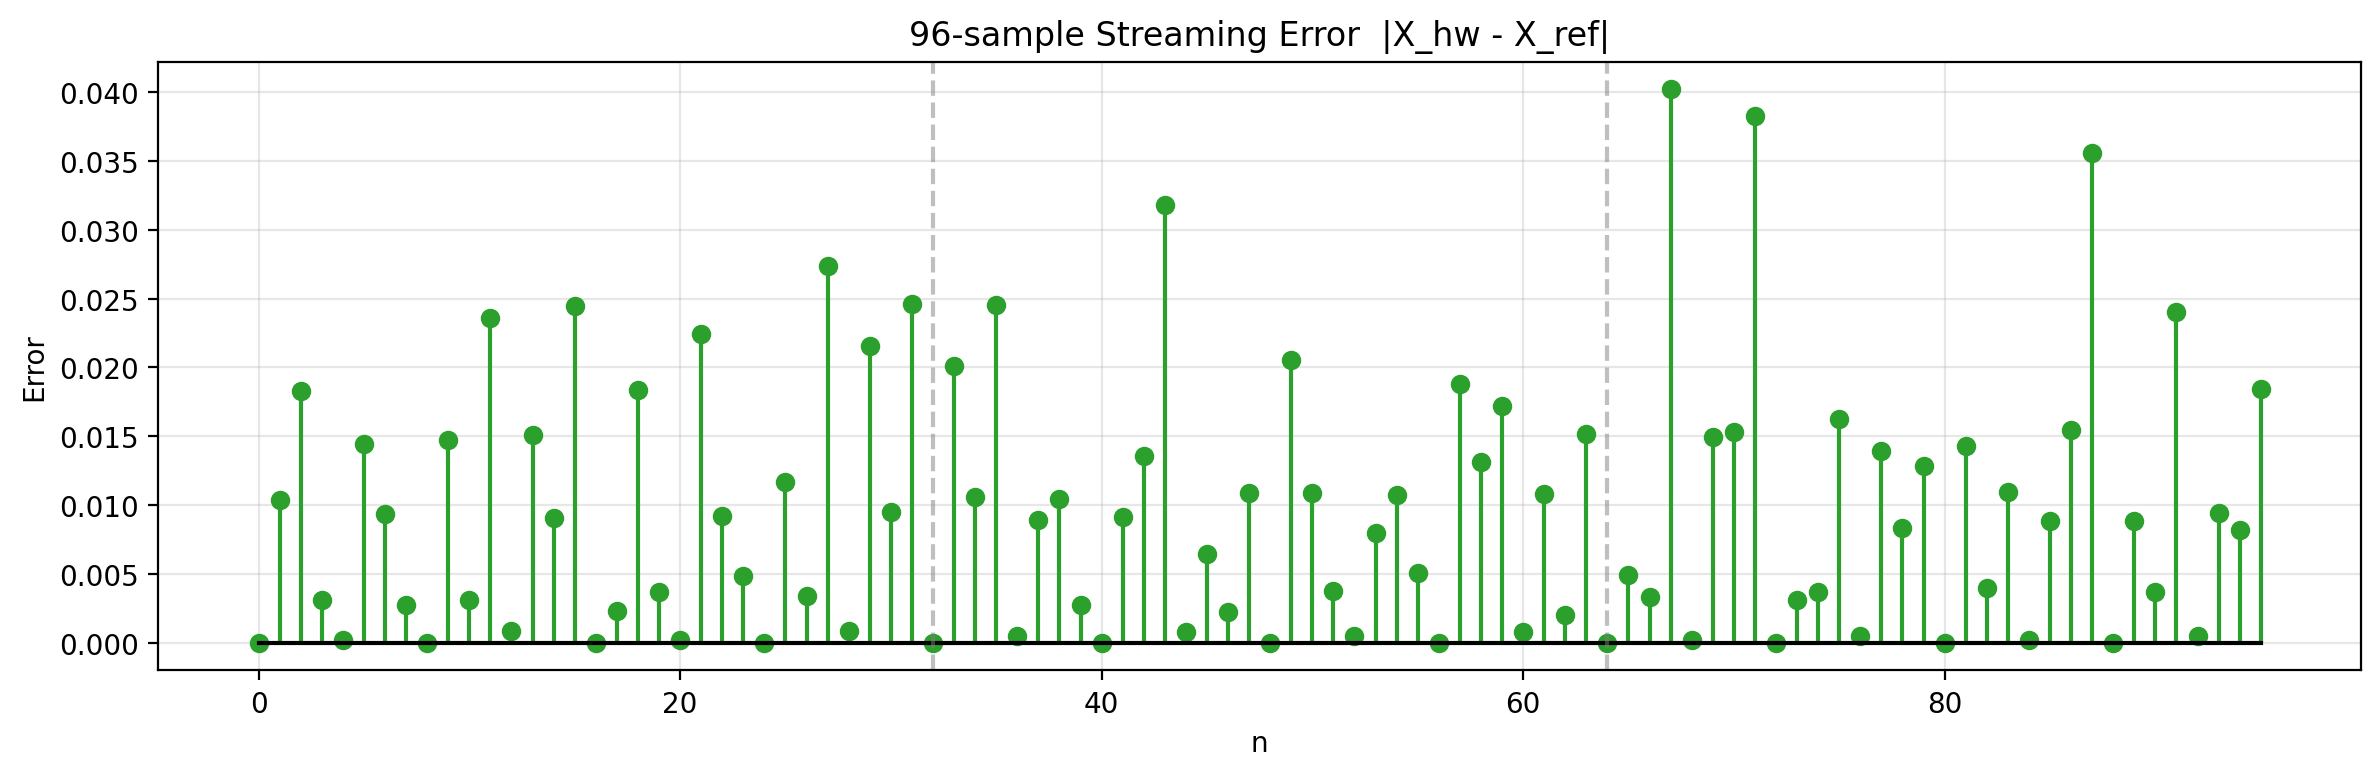

In [17]:
Xhw_re_96 = parse_1s6i9f_hex("./00_TESTBED/src/Q3_BROutRe.dat")
Xhw_im_96 = parse_1s6i9f_hex("./00_TESTBED/src/Q3_BROutIm.dat")
Xhw_96 = Xhw_re_96 + 1j * Xhw_im_96
# 拿 np.fft 當 golden，每 32 點算一次再串接
Xref_96 = np.concatenate([np.fft.fft(own_96[i*32:(i+1)*32]) for i in range(3)])
# SQNR
sig   = np.mean(np.abs(Xref_96) ** 2)
noise = np.mean(np.abs(Xhw_96 - Xref_96) ** 2)
sqnr  = 10 * np.log10(sig / noise)
print(f"96-sample streaming SQNR = {sqnr:.2f} dB")  # 要 ≥ 35 dB
# 96-sample error 圖
n_axis = np.arange(96)
err = np.abs(Xhw_96 - Xref_96)
plt.figure(figsize=(12, 4))
plt.stem(n_axis, err, markerfmt='C2o', linefmt='C2-', basefmt='k-')
for i in range(1, 3):  # 標出 symbol 邊界
    plt.axvline(i*32, color='gray', linestyle='--', alpha=0.5)
plt.title("96-sample Streaming Error  |X_hw - X_ref|")
plt.xlabel("n"); plt.ylabel("Error"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()